In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [5]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.shape

(1338, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Missing Value

In [10]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [11]:
df.isnull().sum().sum()

np.int64(0)

Remove Duplicates

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(1337, 7)

Univariate Analysis

-Numerical Columns

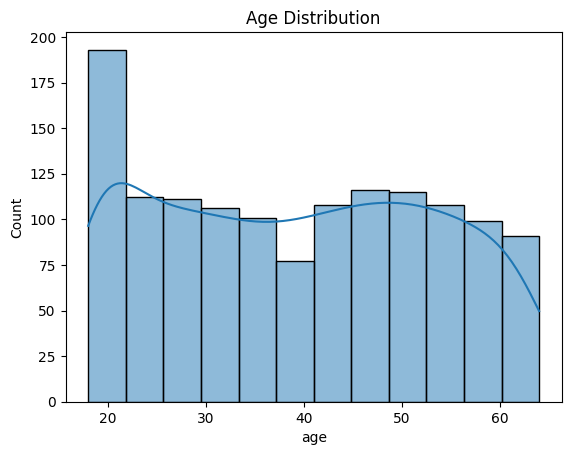

In [14]:
sns.histplot(df['age'], kde='True')
plt.title('Age Distribution')
plt.show()

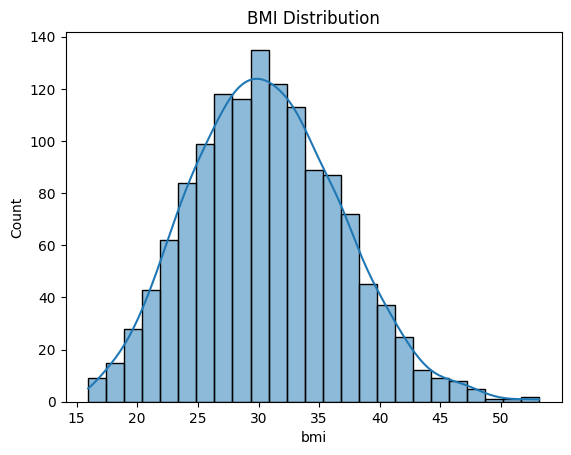

In [15]:
sns.histplot(df['bmi'], kde='True')
plt.title('BMI Distribution')
plt.show()

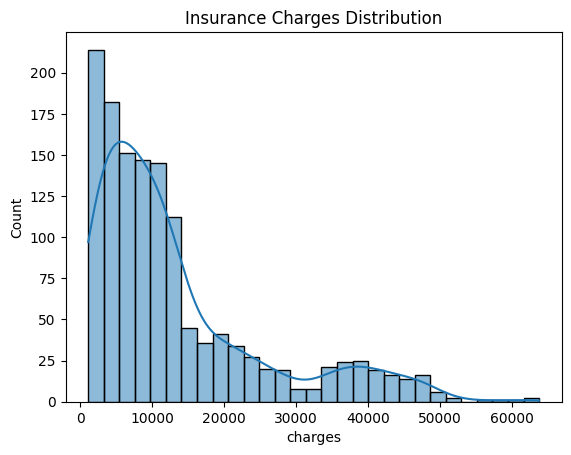

In [16]:
sns.histplot(df['charges'], kde=True)
plt.title('Insurance Charges Distribution')
plt.show()

-Categorical Columns Analysis

In [17]:
df['sex'].value_counts()

,count
sex,
male,675
female,662


<function matplotlib.pyplot.show(close=None, block=None)>

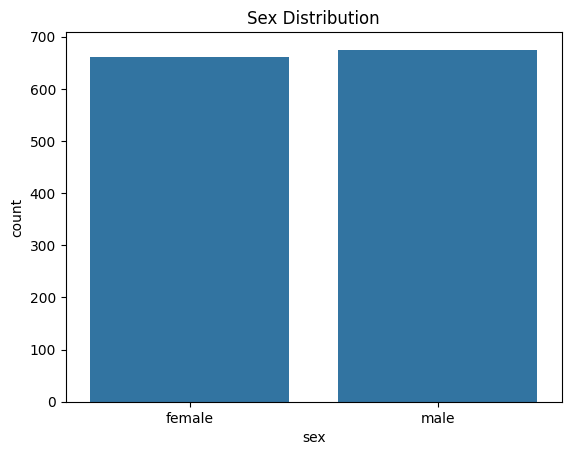

In [18]:
sns.countplot(x='sex', data=df)
plt.title('Sex Distribution')
plt.show

In [19]:
df['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


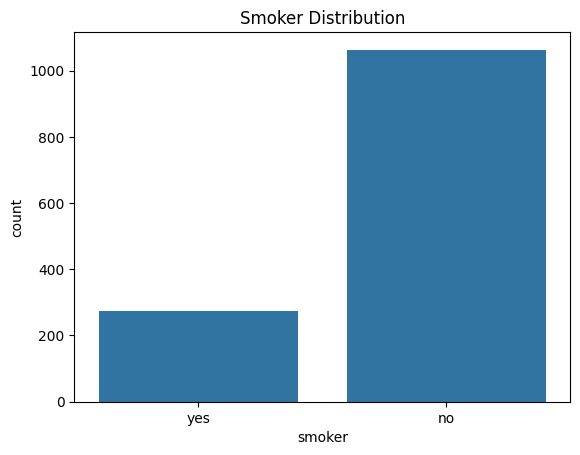

In [20]:
sns.countplot(x='smoker',data=df)
plt.title('Smoker Distribution')
plt.show()

In [21]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


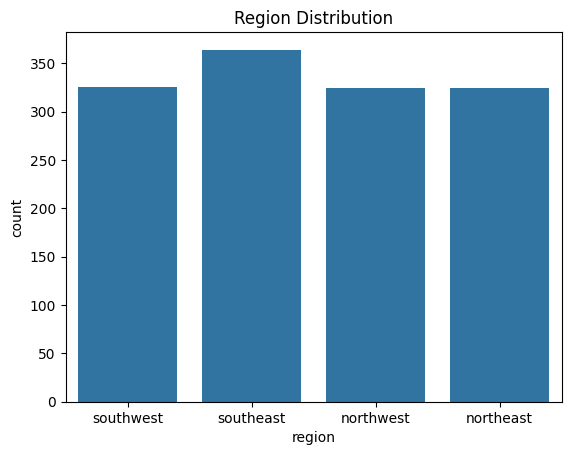

In [22]:
sns.countplot(x='region',data=df)
plt.title('Region Distribution')
plt.show()

Outlier Detection

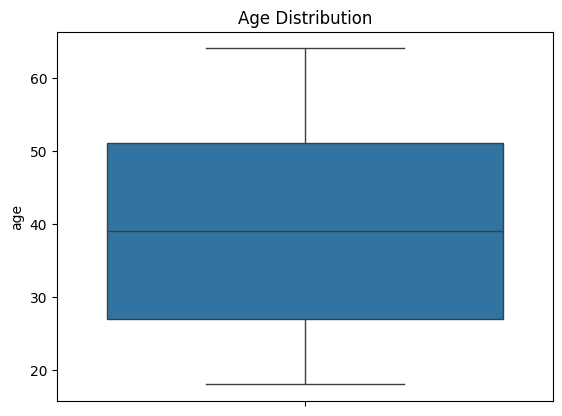

In [23]:
sns.boxplot(df['age'])
plt.title('Age Distribution')
plt.show()

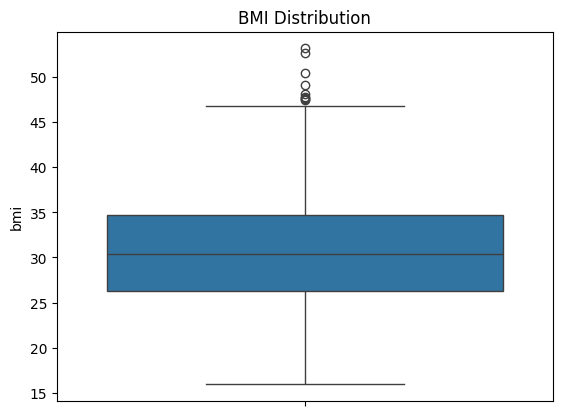

In [24]:
sns.boxplot(df['bmi'])
plt.title('BMI Distribution')
plt.show()

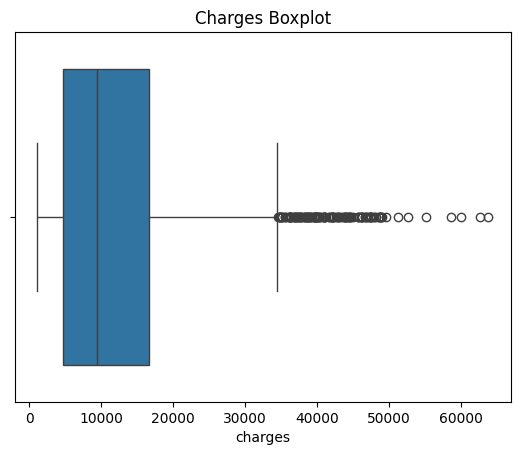

In [25]:
sns.boxplot(x=df['charges'])
plt.title('Charges Boxplot')
plt.show()

Bivariate Analysis

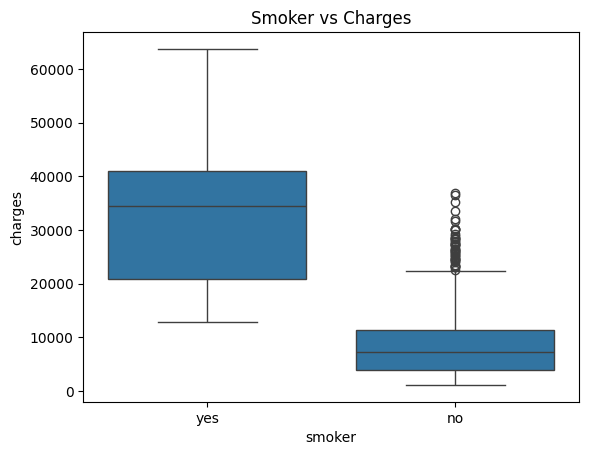

In [34]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Smoker vs Charges')
plt.show()

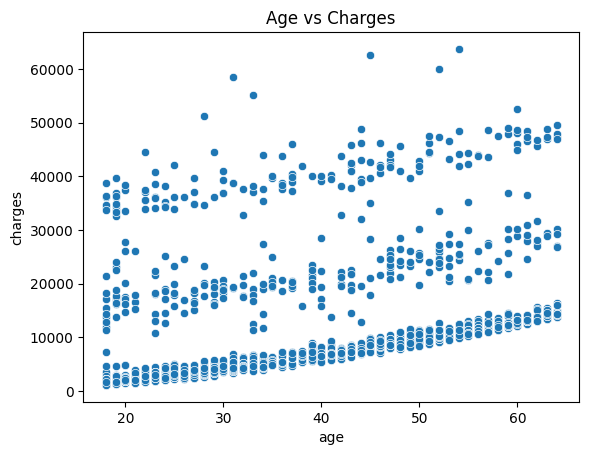

In [28]:
sns.scatterplot(x='age',y='charges',data=df)
plt.title('Age vs Charges')
plt.show()

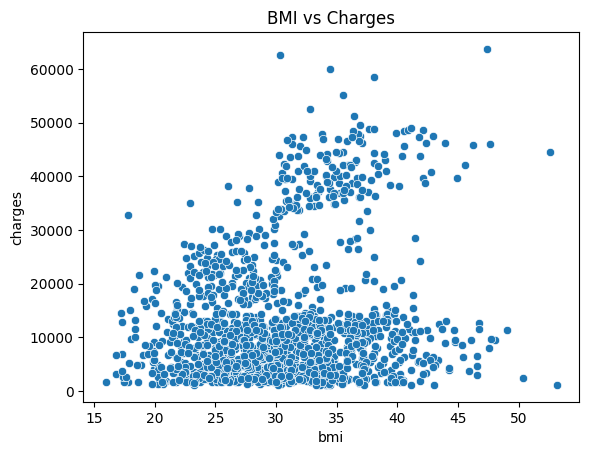

In [29]:
sns.scatterplot(x='bmi',y='charges',data=df)
plt.title('BMI vs Charges')
plt.show()

In [30]:
df.groupby('sex')['charges'].mean()

,charges
sex,
female,12569.578844
male,13974.998864


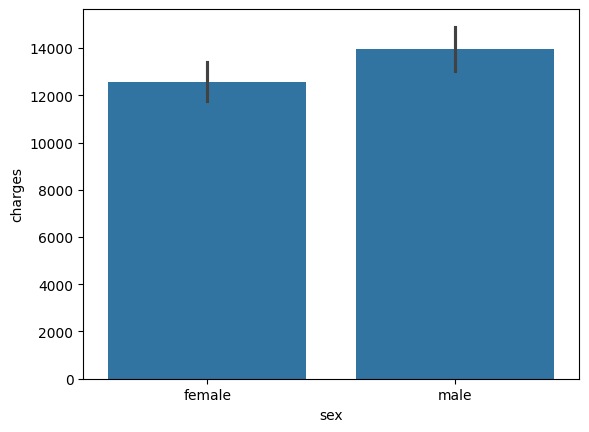

In [31]:
sns.barplot(x='sex', y='charges', data=df)
plt.show()

In [57]:
df.groupby('region')['charges'].mean()

,charges
region,
northeast,13406.384516
northwest,12450.840844
southeast,14735.411438
southwest,12346.937377


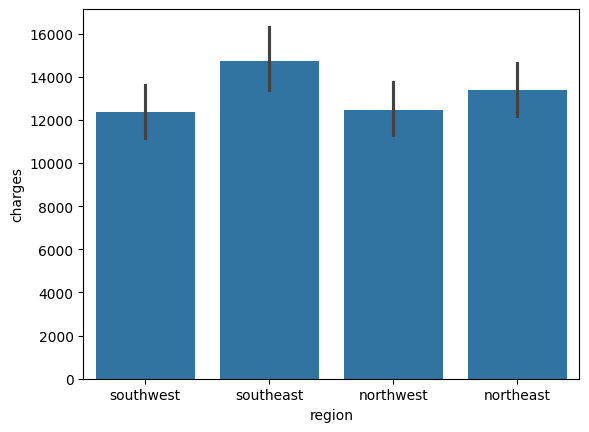

In [58]:
sns.barplot(x='region', y='charges', data=df)
plt.show()

In [41]:
df.select_dtypes(include='number').columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [43]:
corr = df.select_dtypes(include='number').corr()
corr

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


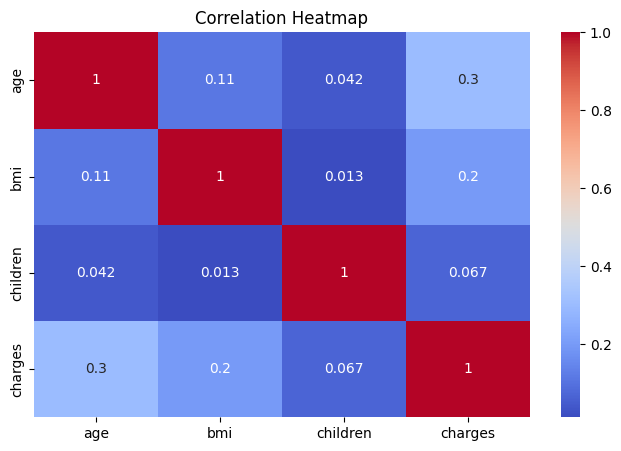

In [56]:
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()